<a href="https://colab.research.google.com/github/pin-chien135/Ocean_current/blob/main/TORO_2015.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install cartopy netcdf4 xarray -q
!apt-get install ffmpeg -y -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.2 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [19]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.interpolate import griddata
from datetime import datetime


In [20]:
# 路徑
DATA_DIR = "/content/"

files = sorted(
    glob.glob(
        os.path.join(
            DATA_DIR,
            "TOTL_TORO_2015_03_*.tuv"
        )
    )
)

print("檔案數量:", len(files))

檔案數量: 744


In [31]:
# 讀取tuv
def read_tuv(filename):

    with open(filename, "r") as f:
        lines = f.readlines()


    for i, line in enumerate(lines):
        if "%TableStart:" in line:
            start = i + 3
            break


    cols = [
        "LOND",
        "LATD",
        "VELU",
        "VELV",
        "VFLG",
        "UQAL",
        "VQAL",
        "CQAL",
        "XDST",
        "YDST",
        "RNGE",
        "BEAR",
        "VELO",
        "HEAD"
    ]


    df = pd.read_csv(
        filename,
        skiprows=start,
        sep=r"\s+",
        names=cols,
        usecols=range(14),
        engine="python",
        on_bad_lines="skip"
    )


    return df

In [32]:
# 從檔名取得時間
def get_time(filename):

    name = os.path.basename(filename)

    parts = name.replace(".tuv","").split("_")


    year = int(parts[2])
    month = int(parts[3])
    day = int(parts[4])
    hour = int(parts[5][:2])


    return datetime(
        year,
        month,
        day,
        hour
    )

In [33]:
# 讀取小時資料
all_data=[]


for f in files:

    print("讀取:",os.path.basename(f))


    df = read_tuv(f)


    # 加時間
    df["time"] = get_time(f)


    all_data.append(df)



data = pd.concat(
    all_data,
    ignore_index=True
)


#print(data.shape)
#print(data.head())

讀取: TOTL_TORO_2015_03_01_0000.tuv
讀取: TOTL_TORO_2015_03_01_0100.tuv
讀取: TOTL_TORO_2015_03_01_0200.tuv
讀取: TOTL_TORO_2015_03_01_0300.tuv
讀取: TOTL_TORO_2015_03_01_0400.tuv
讀取: TOTL_TORO_2015_03_01_0500.tuv
讀取: TOTL_TORO_2015_03_01_0600.tuv
讀取: TOTL_TORO_2015_03_01_0700.tuv
讀取: TOTL_TORO_2015_03_01_0800.tuv
讀取: TOTL_TORO_2015_03_01_0900.tuv
讀取: TOTL_TORO_2015_03_01_1000.tuv
讀取: TOTL_TORO_2015_03_01_1100.tuv
讀取: TOTL_TORO_2015_03_01_1200.tuv
讀取: TOTL_TORO_2015_03_01_1300.tuv
讀取: TOTL_TORO_2015_03_01_1400.tuv
讀取: TOTL_TORO_2015_03_01_1500.tuv
讀取: TOTL_TORO_2015_03_01_1600.tuv
讀取: TOTL_TORO_2015_03_01_1700.tuv
讀取: TOTL_TORO_2015_03_01_1800.tuv
讀取: TOTL_TORO_2015_03_01_1900.tuv
讀取: TOTL_TORO_2015_03_01_2000.tuv
讀取: TOTL_TORO_2015_03_01_2100.tuv
讀取: TOTL_TORO_2015_03_01_2200.tuv
讀取: TOTL_TORO_2015_03_01_2300.tuv
讀取: TOTL_TORO_2015_03_02_0000.tuv
讀取: TOTL_TORO_2015_03_02_0100.tuv
讀取: TOTL_TORO_2015_03_02_0200.tuv
讀取: TOTL_TORO_2015_03_02_0300.tuv
讀取: TOTL_TORO_2015_03_02_0400.tuv
讀取: TOTL_TORO_

In [34]:
# 建立日期
data["date"] = data["time"].dt.date

In [35]:
data[data["VELU"].astype(str).str.contains("BABY")].head()

,LOND,LATD,VELU,VELV,VFLG,UQAL,VQAL,CQAL,XDST,YDST,RNGE,BEAR,VELO,HEAD,time,date
1750,%,1,"""BABY""",21.9261167,120.8306833,155.00,1.5101,"""Meas""",271.0,567,21.9549211,21.2813794,121.1198456,120.1756973,2015-03-01 00:00:00,2015-03-01
3548,%,1,"""BABY""",21.9261167,120.8306833,155.00,1.5101,"""Meas""",271.0,563,21.9540823,21.2739581,121.1259730,120.1538062,2015-03-01 01:00:00,2015-03-01
5362,%,1,"""BABY""",21.9261167,120.8306833,155.00,1.5101,"""Meas""",271.0,570,21.9587392,21.2851169,121.1198456,120.1403073,2015-03-01 02:00:00,2015-03-01
7178,%,1,"""BABY""",21.9261167,120.8306833,155.00,1.5101,"""Meas""",271.0,573,21.9587392,21.2851169,121.1198456,120.1403073,2015-03-01 03:00:00,2015-03-01
8977,%,1,"""BABY""",21.9261167,120.8306833,155.00,1.5101,"""Meas""",271.0,572,21.9587392,21.2851169,121.1259730,120.1465985,2015-03-01 04:00:00,2015-03-01


In [38]:
# 轉數值
data = pd.concat(
    all_data,
    ignore_index=True
)
for c in ["LOND","LATD","VELU","VELV","VFLG"]:

    data[c] = pd.to_numeric(
        data[c],
        errors="coerce"
    )

data = data.dropna(
    subset=[
        "LOND",
        "LATD",
        "VELU",
        "VELV"
    ]
)

In [42]:
# QC
data = data[
    data["VFLG"] == 0
]
#print(data.dtypes)

In [44]:
# 日平均
daily = (
    data
    .groupby(
        [
            #"date",
            "LOND",
            "LATD"
        ]
    )
    [["VELU","VELV"]]
    .mean()
    .reset_index()
)

In [47]:
# 月平均
monthly = (
    daily
    .groupby(
        [
            "LOND",
            "LATD"
        ]
    )
    [["VELU","VELV"]]
    .mean()
    .reset_index()
)


print(monthly.shape)

(1750, 4)


In [48]:
# 流速
monthly["Speed"] = np.sqrt(
    monthly["VELU"]**2 +
    monthly["VELV"]**2
)
# 定義
lon = monthly["LOND"].values
lat = monthly["LATD"].values

u = monthly["VELU"].values
v = monthly["VELV"].values
speed = monthly["Speed"].values

In [49]:
# 建立規則網格
lon_grid = np.linspace(
    lon.min(),
    lon.max(),
    150
)
lat_grid = np.linspace(
    lat.min(),
    lat.max(),
    150
)
Lon,Lat = np.meshgrid(
    lon_grid,
    lat_grid
)



# 插值
U_grid = griddata(
    (lon,lat),
    u,
    (Lon,Lat),
    method="linear"
)

V_grid = griddata(
    (lon,lat),
    v,
    (Lon,Lat),
    method="linear"
)


Speed_grid = np.sqrt(
    U_grid**2+
    V_grid**2
)

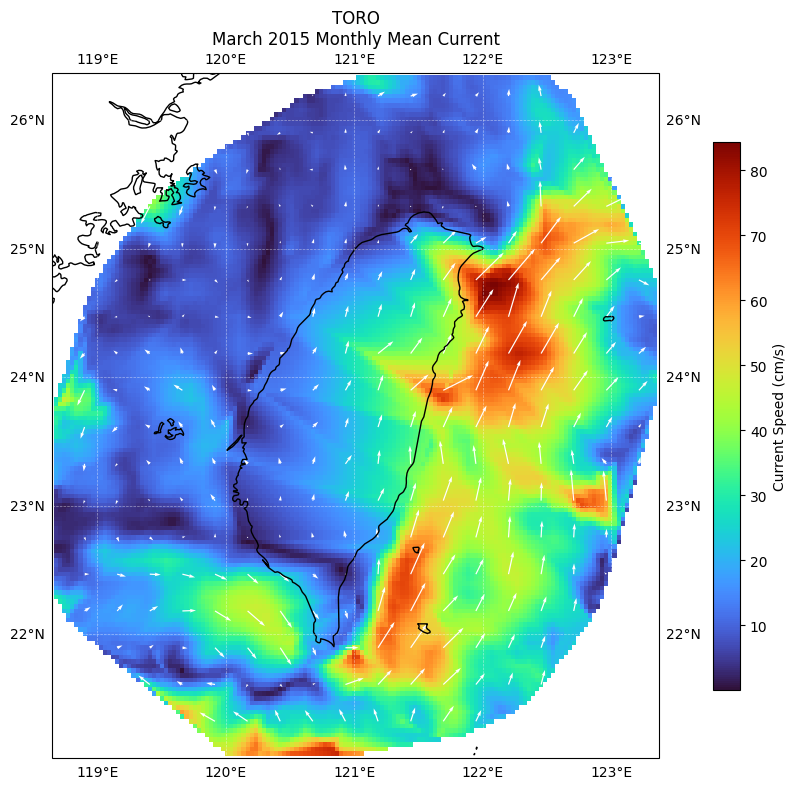

<Figure size 640x480 with 0 Axes>

In [51]:
# 月平均海流圖
fig = plt.figure(
    figsize=(11,8)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

ax.set_extent(
    [
        lon.min(),
        lon.max(),
        lat.min(),
        lat.max()
    ]
)

ax.coastlines(
    resolution="10m"
)

# 底圖
pcm=ax.pcolormesh(
    Lon,
    Lat,
    Speed_grid,
    cmap="turbo",
    shading="auto",
    transform=ccrs.PlateCarree()
)
cbar=plt.colorbar(
    pcm,
    ax=ax,
    shrink=0.8
)

cbar.set_label(
    "Current Speed (cm/s)"
)



# 箭頭
step=8
q=ax.quiver(
    Lon[::step,::step],
    Lat[::step,::step],
    U_grid[::step,::step],
    V_grid[::step,::step],
    color="white",
    scale=1200,
    width=0.002,
    transform=ccrs.PlateCarree()
)

ax.quiverkey(
    q,
    0.85,
    -0.08,
    50,
    "50 cm/s",
    labelpos="E"
)

ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    linestyle="--",
    color="white",
    alpha=0.5
)

plt.title(
    "TORO\nMarch 2015 Monthly Mean Current",
    fontsize=12
)


plt.tight_layout()
plt.show()
#plt.savefig('2015 March.png')